# Section 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Section 2 — Data Loading & Merging

In [2]:
df = pd.read_csv('../data/athlete_events.csv')
regions = pd.read_csv('../data/noc_regions.csv')

In [3]:
df = pd.merge(df, regions, on='NOC', how='left')

In [4]:
df.head(5)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,notes
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,China,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,China,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,Denmark,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,Denmark,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,Netherlands,NaN


In [5]:
print(df.shape)
print(df.columns.tolist())
print(df.info())
print(df.describe())

(271116, 17)
['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'region', 'notes']
<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  float64
 5   Weight  208241 non-null  float64
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   Year    271116 non-null  int64  
 10  Season  271116 non-null  str    
 11  City    271116 non-null  str    
 12  Sport   271116 non-null  str    
 13  Event   271116 non-null  str    
 14  Medal   39783 non-null   str    
 15  region  270746 non-null  str    
 16  notes   5039 non-null    str    
dtypes: float64(3), 

In [6]:
print(df.isnull().sum())

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
region       370
notes     266077
dtype: int64


In [7]:
print("Sports:", df['Sport'].nunique())
print("Countries:", df['region'].nunique())
print("Years:", df['Year'].min(), "to", df['Year'].max())
print("Athletes:", df['Name'].nunique())

Sports: 66
Countries: 205
Years: 1896 to 2016
Athletes: 134732


# Section 3 — Data Cleaning

In [8]:
df.drop(columns=['notes'], inplace=True)

In [9]:
df['Medal'] = df['Medal'].fillna('No Medal')

In [10]:
print(df['Medal'].value_counts())
print(df['Medal'].isnull().sum())

Medal
No Medal    231333
Gold         13372
Bronze       13295
Silver       13116
Name: count, dtype: int64
0


In [11]:
df['Medal_Won'] = df['Medal'].apply(lambda x: 0 if x == 'No Medal' else 1)

In [12]:
df['Age'] = df.groupby('Sport')['Age'].transform(
    lambda x: x.fillna(x.median())
)

In [13]:
df['Height'] = df.groupby('Sport')['Height'].transform(
    lambda x: x.fillna(x.median())
)

In [14]:
df['Weight'] = df.groupby('Sport')['Weight'].transform(
    lambda x: x.fillna(x.median())
)

In [15]:
df.dropna(subset=['region'], inplace=True)

In [16]:
df['Height'] = df['Height'].fillna(df['Height'].median())
df['Weight'] = df['Weight'].fillna(df['Weight'].median())

In [17]:
print("Shape after cleaning:", df.shape)
print("\nMissing values remaining:")
print(df.isnull().sum())
print("\nMedal_Won value counts:")
print(df['Medal_Won'].value_counts())

Shape after cleaning: (270746, 17)

Missing values remaining:
ID           0
Name         0
Sex          0
Age          0
Height       0
Weight       0
Team         0
NOC          0
Games        0
Year         0
Season       0
City         0
Sport        0
Event        0
Medal        0
region       0
Medal_Won    0
dtype: int64

Medal_Won value counts:
Medal_Won
0    230972
1     39774
Name: count, dtype: int64


# Section 4 — Exploratory Data Analysis

In [18]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 4.1 Overview Analysis

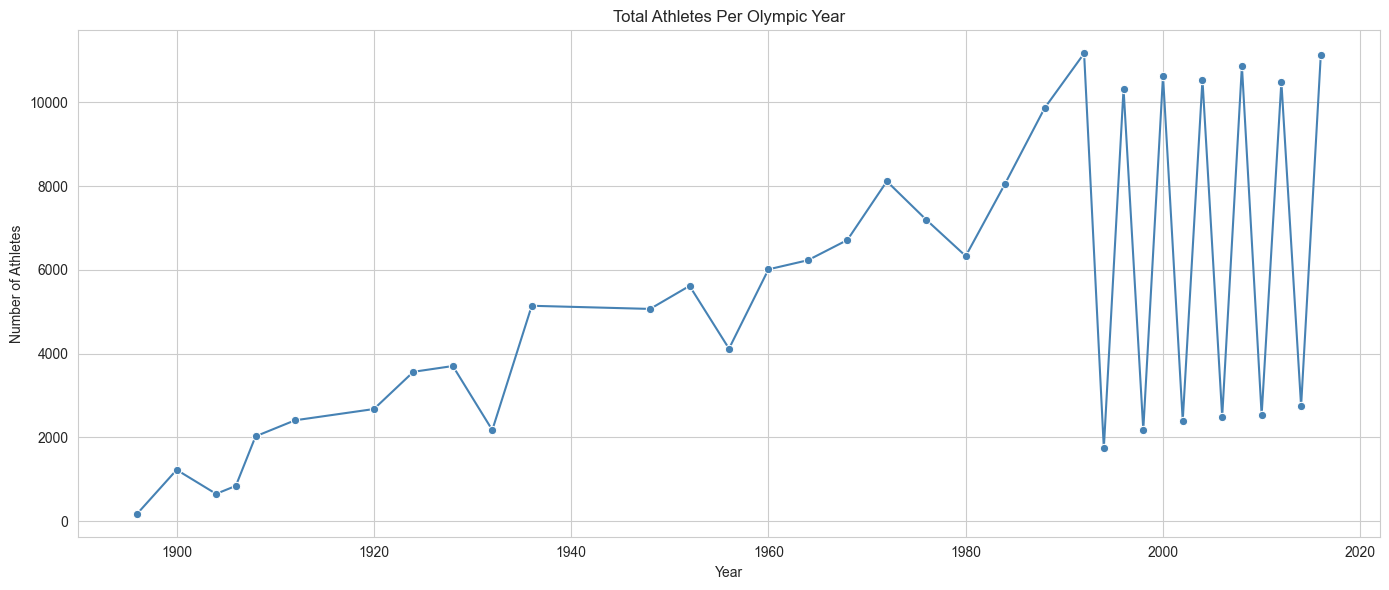

In [19]:
athletes_per_year = df.groupby('Year')['ID'].nunique().reset_index()
athletes_per_year.columns = ['Year', 'Athletes']

plt.figure(figsize=(14, 6))
sns.lineplot(data=athletes_per_year, x='Year', y='Athletes', marker='o', color='steelblue')
plt.title('Total Athletes Per Olympic Year')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.tight_layout()
plt.savefig('../graphs/athletes_per_year.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
df.groupby('Year')['ID'].nunique()

Year
1896      176
1900     1224
1904      650
1906      841
1908     2024
1912     2407
1920     2676
1924     3565
1928     3703
1932     2174
1936     5142
1948     5067
1952     5617
1956     4118
1960     6012
1964     6230
1968     6713
1972     8115
1976     7196
1980     6330
1984     8062
1988     9865
1992    11169
1994     1738
1996    10325
1998     2179
2000    10633
2002     2399
2004    10541
2006     2494
2008    10871
2010     2536
2012    10491
2014     2745
2016    11143
Name: ID, dtype: int64

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\1496857164.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_counts, x='Season', y='ID', palette=['#378ADD', '#B5D4F4'])


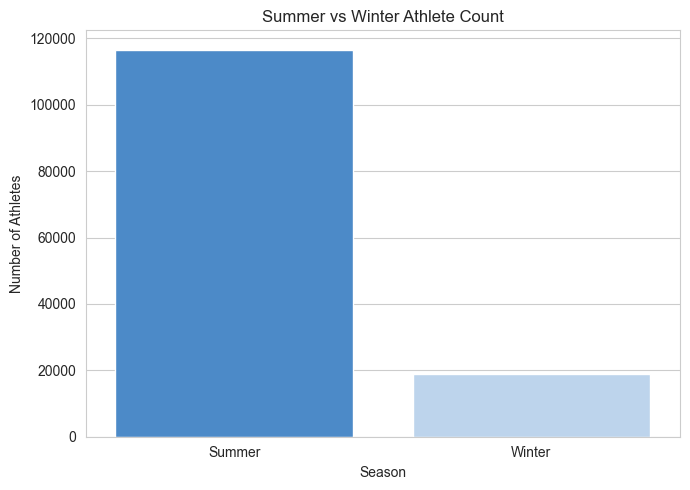

In [21]:
season_counts = df.groupby('Season')['ID'].nunique().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=season_counts, x='Season', y='ID', palette=['#378ADD', '#B5D4F4'])
plt.title('Summer vs Winter Athlete Count')
plt.xlabel('Season')
plt.ylabel('Number of Athletes')
plt.tight_layout()
plt.savefig('../graphs/season_split.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\3310863876.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medal_counts, x='Medal', y='Count', palette=colors)


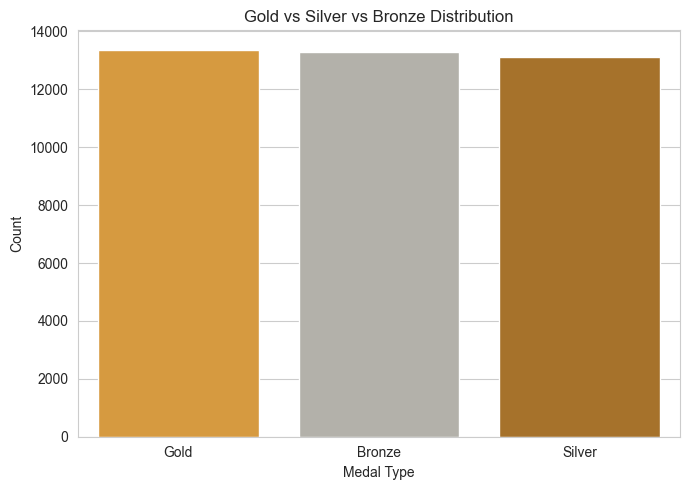

In [22]:
medal_counts = df[df['Medal'] != 'No Medal']['Medal'].value_counts().reset_index()
medal_counts.columns = ['Medal', 'Count']

plt.figure(figsize=(7, 5))
colors = ['#EF9F27', '#B4B2A9', '#BA7517']
sns.barplot(data=medal_counts, x='Medal', y='Count', palette=colors)
plt.title('Gold vs Silver vs Bronze Distribution')
plt.xlabel('Medal Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../graphs/medal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ## 4.2 Country Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\3553357611.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_countries, x='Medals', y='Country', palette='Blues_r')


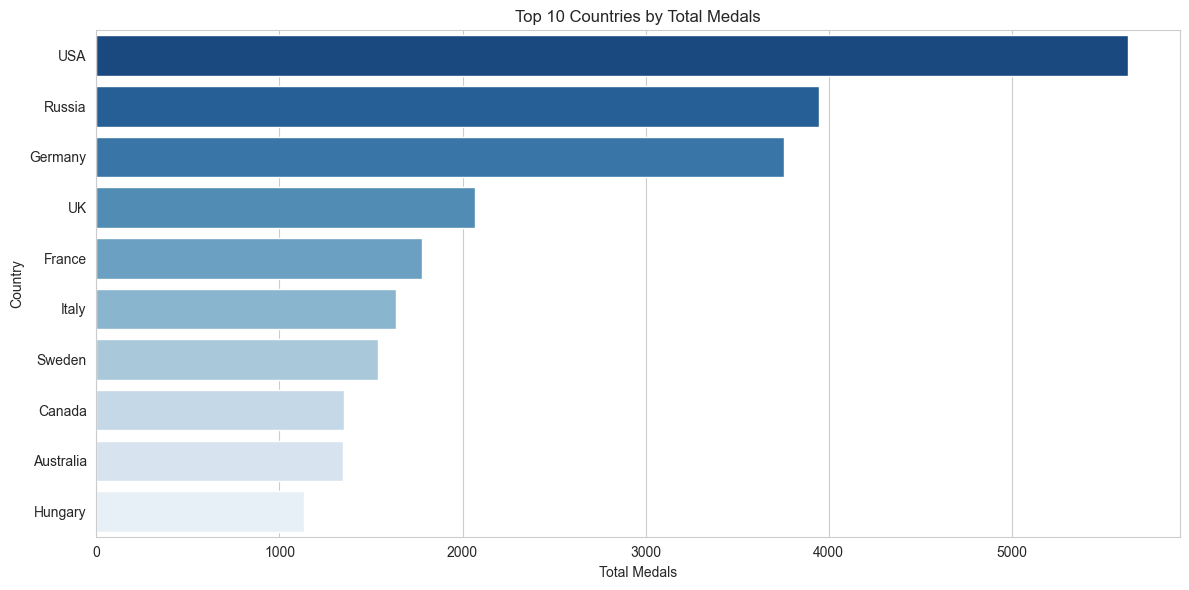

In [23]:
top_countries = df[df['Medal'] != 'No Medal'].groupby('region')['Medal'].count().reset_index()
top_countries.columns = ['Country', 'Medals']
top_countries = top_countries.sort_values('Medals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_countries, x='Medals', y='Country', palette='Blues_r')
plt.title('Top 10 Countries by Total Medals')
plt.xlabel('Total Medals')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../graphs/top_countries_medal.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
top_countries.sort_values('Medals', ascending=False).head(10)

,Country,Medals
125,USA,5637
100,Russia,3947
41,Germany,3756
124,UK,2068
38,France,1777
57,Italy,1637
112,Sweden,1536
18,Canada,1352
4,Australia,1349
48,Hungary,1135


C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\2918134702.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=gold_countries, x='Gold Medals', y='Country', palette='YlOrBr')


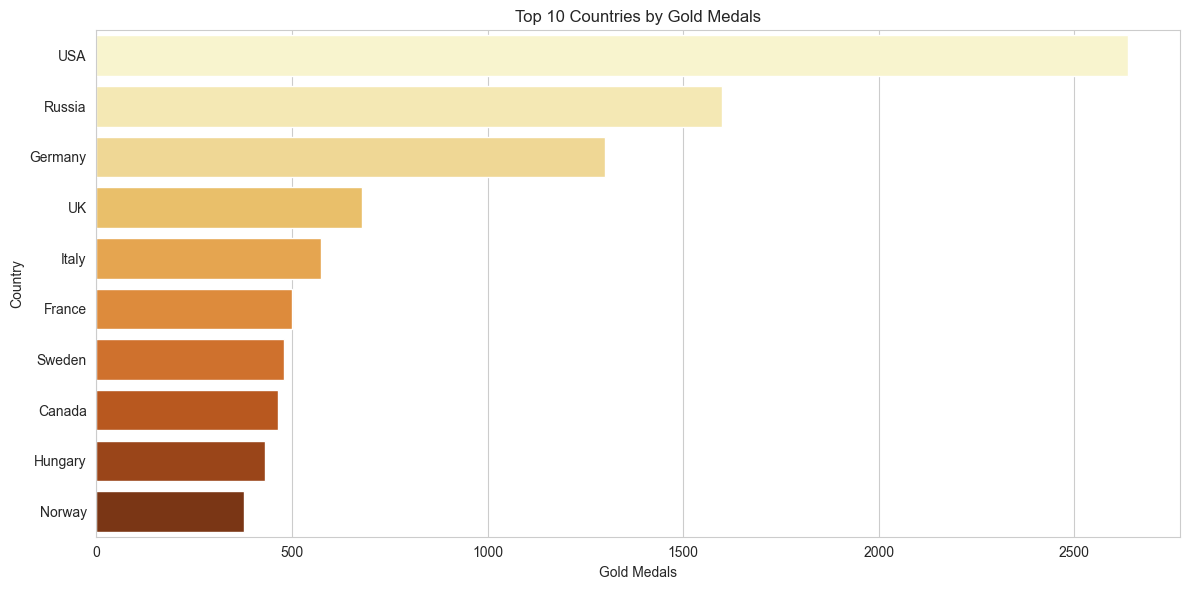

In [25]:
gold_countries = df[df['Medal'] == 'Gold'].groupby('region')['Medal'].count().reset_index()
gold_countries.columns = ['Country', 'Gold Medals']
gold_countries = gold_countries.sort_values('Gold Medals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=gold_countries, x='Gold Medals', y='Country', palette='YlOrBr')
plt.title('Top 10 Countries by Gold Medals')
plt.xlabel('Gold Medals')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../graphs/top_countries_gold.png', dpi=150, bbox_inches='tight')
plt.show()

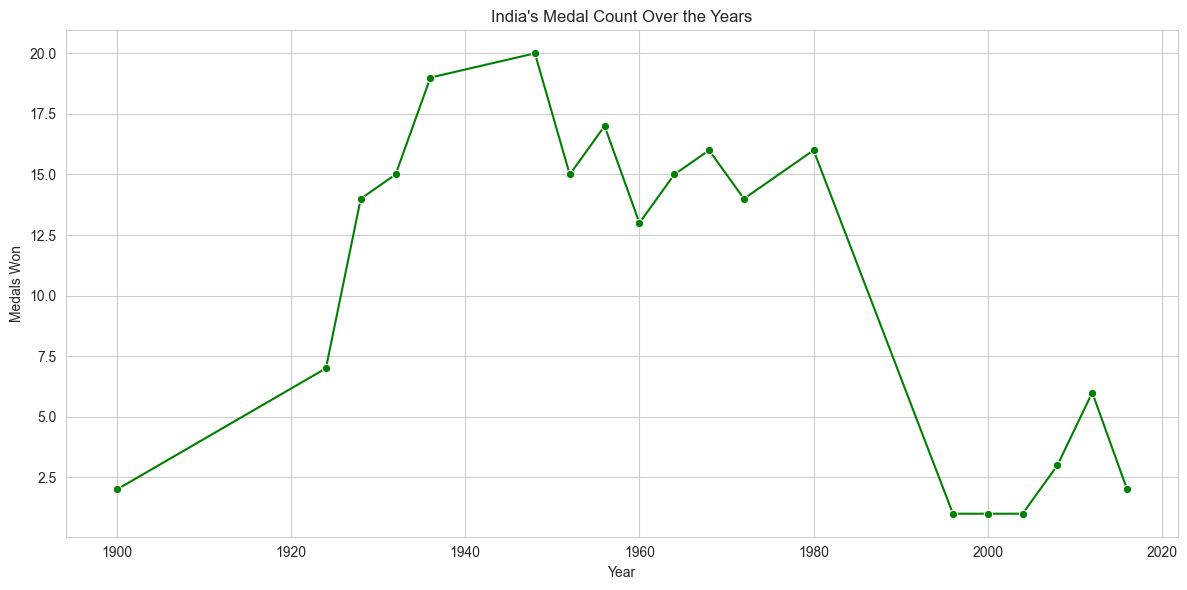

In [26]:
india = df[(df['region'] == 'India') & (df['Medal'] != 'No Medal')]
india_trend = india.groupby('Year')['Medal'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=india_trend, x='Year', y='Medal', marker='o', color='green')
plt.title("India's Medal Count Over the Years")
plt.xlabel('Year')
plt.ylabel('Medals Won')
plt.tight_layout()
plt.savefig('../graphs/india_medal_trend.png', dpi=150, bbox_inches='tight')
plt.show()

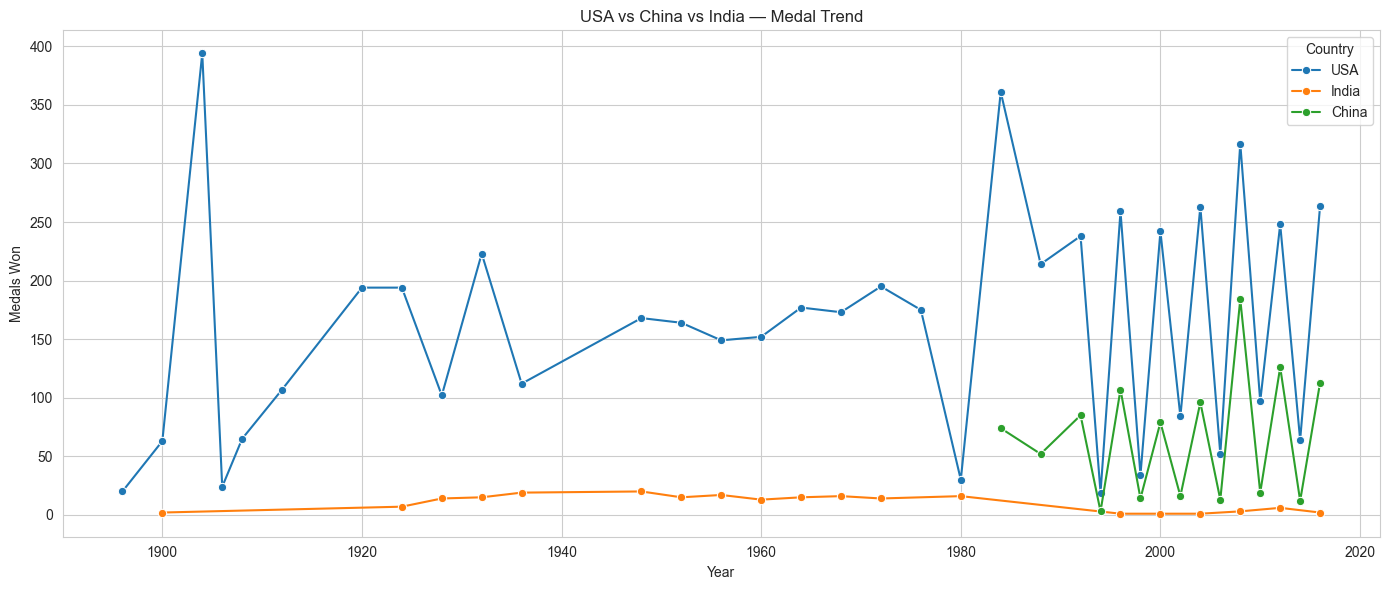

In [27]:
countries = ['USA', 'China', 'India']
country_trend = df[(df['region'].isin(countries)) & (df['Medal'] != 'No Medal')]
country_trend = country_trend.groupby(['Year', 'region'])['Medal'].count().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=country_trend, x='Year', y='Medal', hue='region', marker='o')
plt.title('USA vs China vs India — Medal Trend')
plt.xlabel('Year')
plt.ylabel('Medals Won')
plt.legend(title='Country')
plt.tight_layout()
plt.savefig('../graphs/country_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.3 Gender Trends

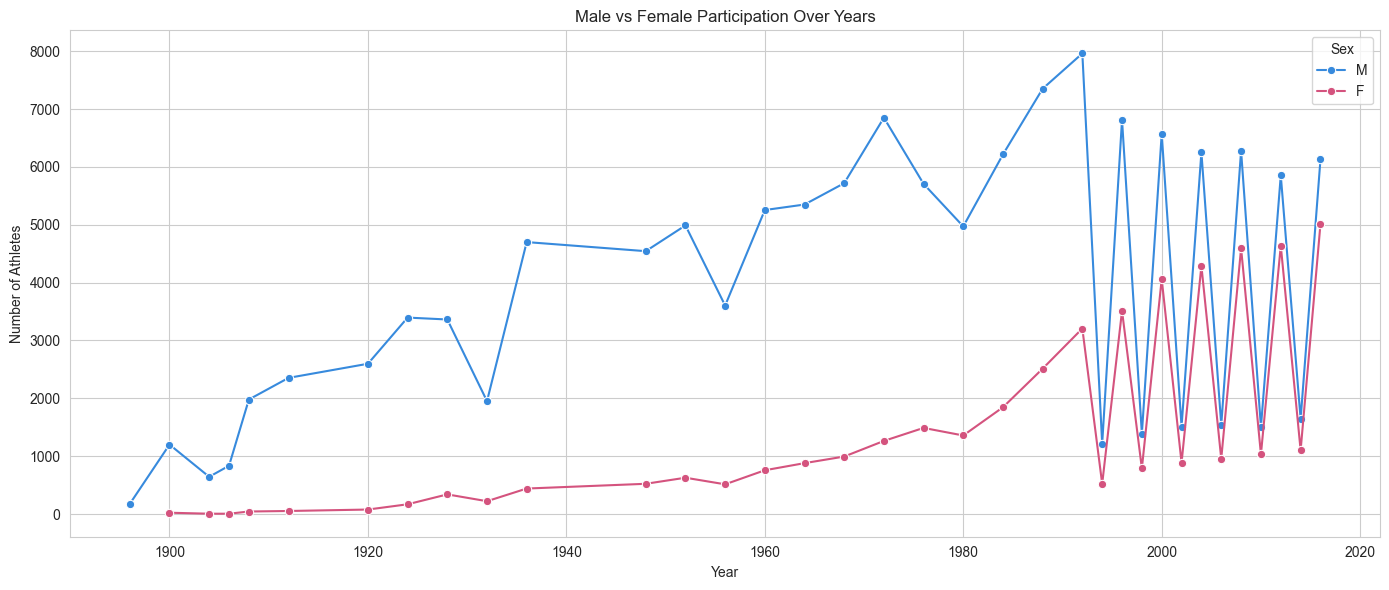

In [28]:
gender_year = df.groupby(['Year', 'Sex'])['ID'].nunique().reset_index()
gender_year.columns = ['Year', 'Sex', 'Athletes']

plt.figure(figsize=(14, 6))
sns.lineplot(data=gender_year, x='Year', y='Athletes', hue='Sex', marker='o', palette=['#378ADD', '#D4537E'])
plt.title('Male vs Female Participation Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Athletes')
plt.legend(title='Sex')
plt.tight_layout()
plt.savefig('../graphs/gender_participation.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
df.groupby(['Year', 'Sex'])['ID'].nunique()

Year  Sex
1896  M       176
1900  F        23
      M      1201
1904  F         6
      M       644
             ... 
2012  M      5853
2014  F      1102
      M      1643
2016  F      5014
      M      6129
Name: ID, Length: 69, dtype: int64

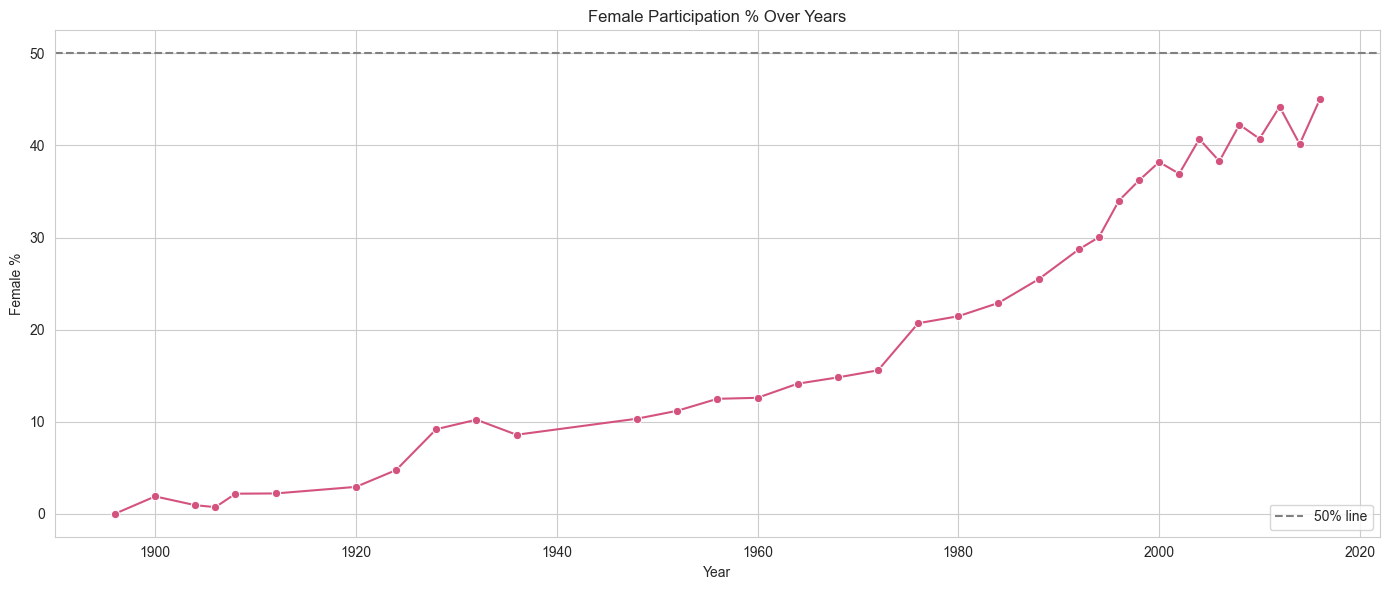

In [30]:
gender_pivot = gender_year.pivot(index='Year', columns='Sex', values='Athletes').fillna(0)
gender_pivot['Female %'] = (gender_pivot['F'] / (gender_pivot['M'] + gender_pivot['F'])) * 100

plt.figure(figsize=(14, 6))
sns.lineplot(data=gender_pivot, x=gender_pivot.index, y='Female %', marker='o', color='#D4537E')
plt.title('Female Participation % Over Years')
plt.xlabel('Year')
plt.ylabel('Female %')
plt.axhline(y=50, color='gray', linestyle='--', label='50% line')
plt.legend()
plt.tight_layout()
plt.savefig('../graphs/female_percentage.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
gender_year.pivot(index='Year', columns='Sex', values='Athletes').fillna(0)

Sex,F,M
Year,,
1896,0.0,176.0
1900,23.0,1201.0
1904,6.0,644.0
1906,6.0,835.0
1908,44.0,1980.0
1912,53.0,2354.0
1920,78.0,2598.0
1924,169.0,3396.0
1928,340.0,3363.0


C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\117541729.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=medal_gender, x='Sex', y='Medal', palette=['#378ADD', '#D4537E'])


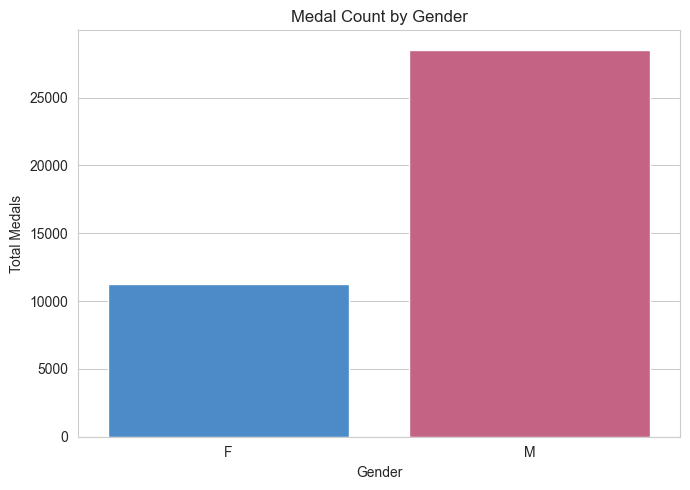

In [32]:
medal_gender = df[df['Medal'] != 'No Medal'].groupby('Sex')['Medal'].count().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=medal_gender, x='Sex', y='Medal', palette=['#378ADD', '#D4537E'])
plt.title('Medal Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Medals')
plt.tight_layout()
plt.savefig('../graphs/medal_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.4 Athlete Stats

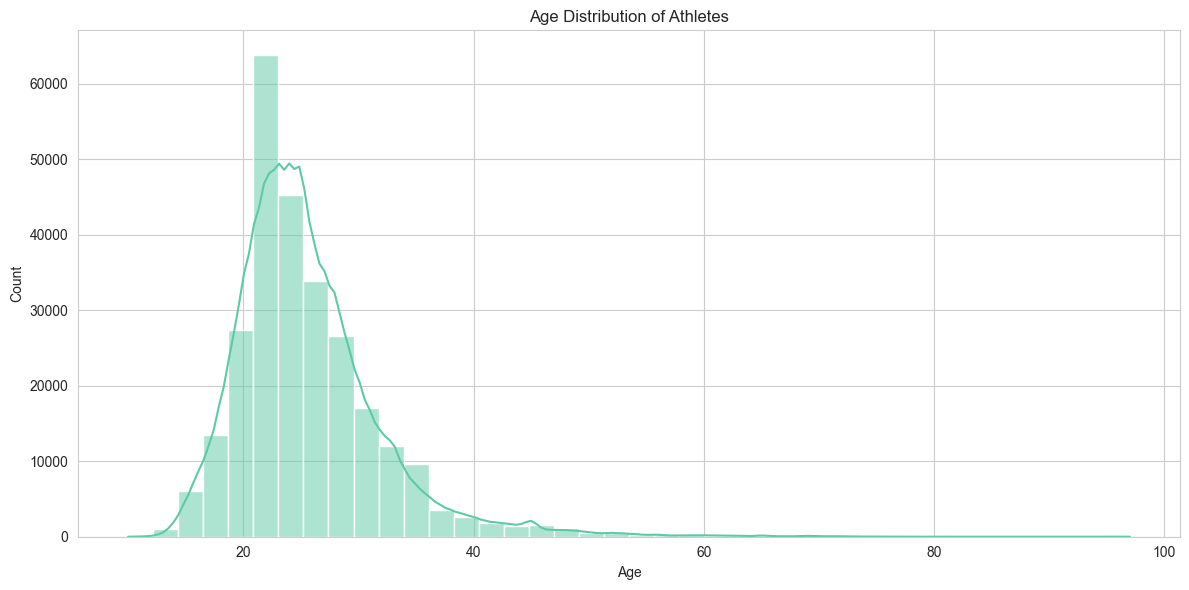

In [33]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Age'].dropna(), bins=40, color='#5DCAA5', kde=True)
plt.title('Age Distribution of Athletes')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../graphs/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\3019533938.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['Medal'] != 'No Medal'], x='Medal', y='Age',


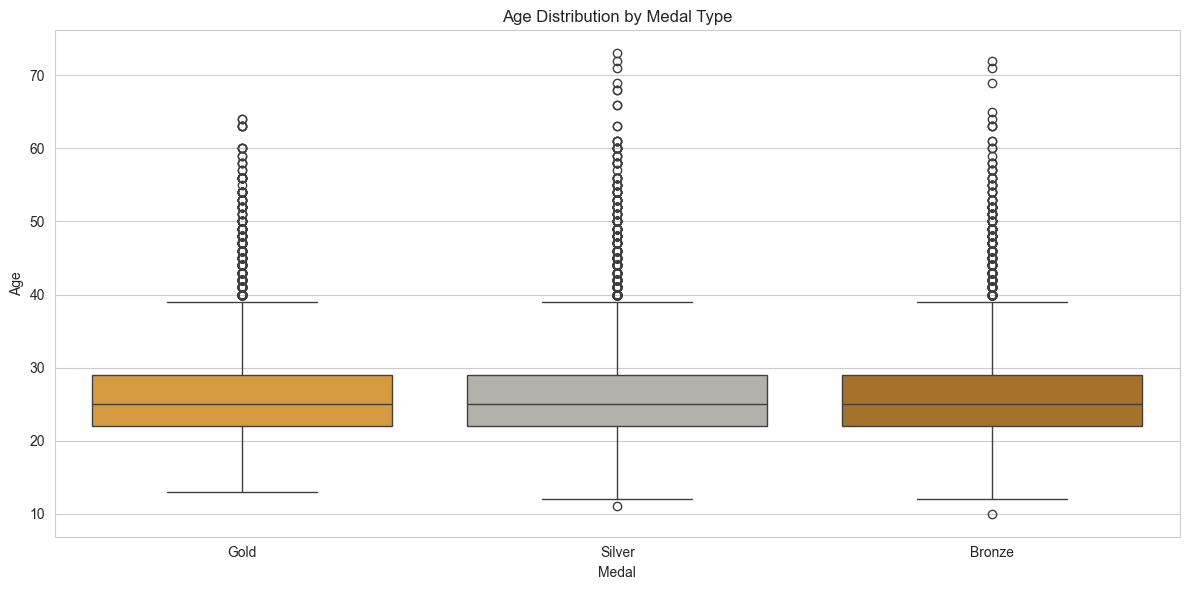

In [34]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[df['Medal'] != 'No Medal'], x='Medal', y='Age', 
            palette=['#EF9F27', '#B4B2A9', '#BA7517'],
            order=['Gold', 'Silver', 'Bronze'])
plt.title('Age Distribution by Medal Type')
plt.xlabel('Medal')
plt.ylabel('Age')
plt.tight_layout()
plt.savefig('../graphs/age_by_medal.png', dpi=150, bbox_inches='tight')
plt.show()

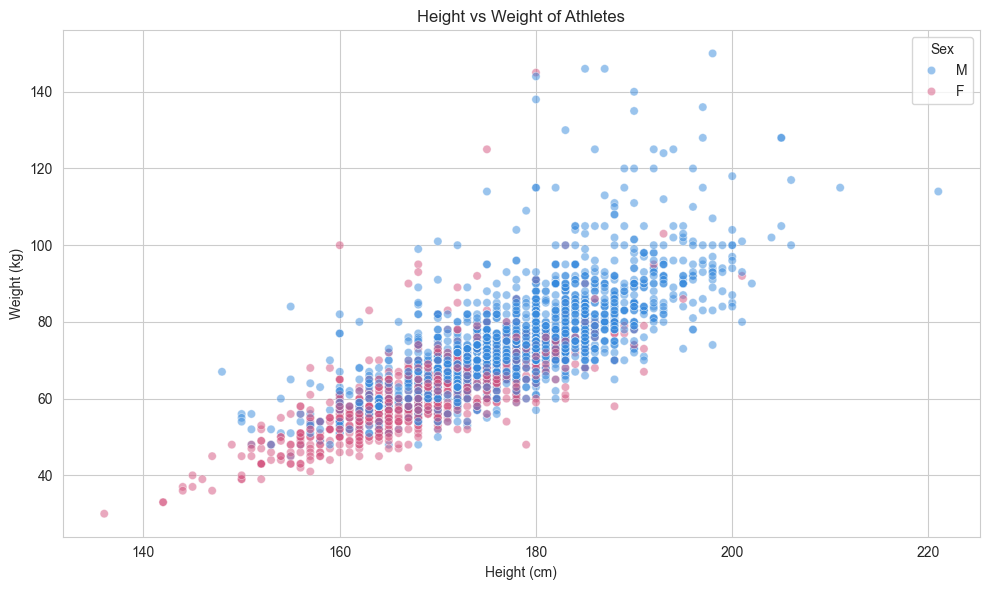

In [35]:
sample = df.dropna(subset=['Height', 'Weight']).sample(3000, random_state=42)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=sample, x='Height', y='Weight', hue='Sex', 
                alpha=0.5, palette=['#378ADD', '#D4537E'])
plt.title('Height vs Weight of Athletes')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.tight_layout()
plt.savefig('../graphs/height_vs_weight.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
df.dropna(subset=['Height', 'Weight']).sample(3000, random_state=42)

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal,region,Medal_Won
54839,28104,Manlio Di Rosa,M,21.0,178.0,72.0,Italy,ITA,1936 Summer,1936,Summer,Berlin,Fencing,"Fencing Men's Foil, Team",Gold,Italy,1
29445,15204,Ivana Brkljai,F,17.0,170.0,82.0,Croatia,CRO,2000 Summer,2000,Summer,Sydney,Athletics,Athletics Women's Hammer Throw,No Medal,Croatia,0
182736,91845,Gabriella Paruzzi,F,28.0,173.0,62.0,Italy,ITA,1998 Winter,1998,Winter,Nagano,Cross Country Skiing,Cross Country Skiing Women's 15 kilometres,No Medal,Italy,0
221976,111556,Tommy Sigurd Skaarberg,M,27.0,185.0,85.0,Norway,NOR,1988 Winter,1988,Winter,Calgary,Ice Hockey,Ice Hockey Men's Ice Hockey,No Medal,Norway,0
132432,66651,Christine Laprell,F,17.0,171.0,57.0,West Germany,FRG,1968 Winter,1968,Winter,Grenoble,Alpine Skiing,Alpine Skiing Women's Slalom,No Medal,Germany,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135551,68203,Lee Yeong-Seon,F,22.0,182.0,72.0,South Korea,KOR,1984 Summer,1984,Summer,Los Angeles,Volleyball,Volleyball Women's Volleyball,No Medal,South Korea,0
173135,87022,Edgar Aleksander Norwerth,M,48.0,175.0,76.0,Poland,POL,1932 Summer,1932,Summer,Los Angeles,Art Competitions,"Art Competitions Mixed Architecture, Unknown E...",No Medal,Poland,0
189754,95300,Paolo Pizzo,M,33.0,180.0,70.0,Italy,ITA,2016 Summer,2016,Summer,Rio de Janeiro,Fencing,"Fencing Men's epee, Team",Silver,Italy,1
30268,15630,Scott Alexander Brownlee,M,27.0,197.0,96.0,New Zealand,NZL,1996 Summer,1996,Summer,Atlanta,Rowing,Rowing Men's Coxless Fours,No Medal,New Zealand,0


C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\3714968174.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_athletes, x='Medals', y='Athlete', palette='YlOrBr')


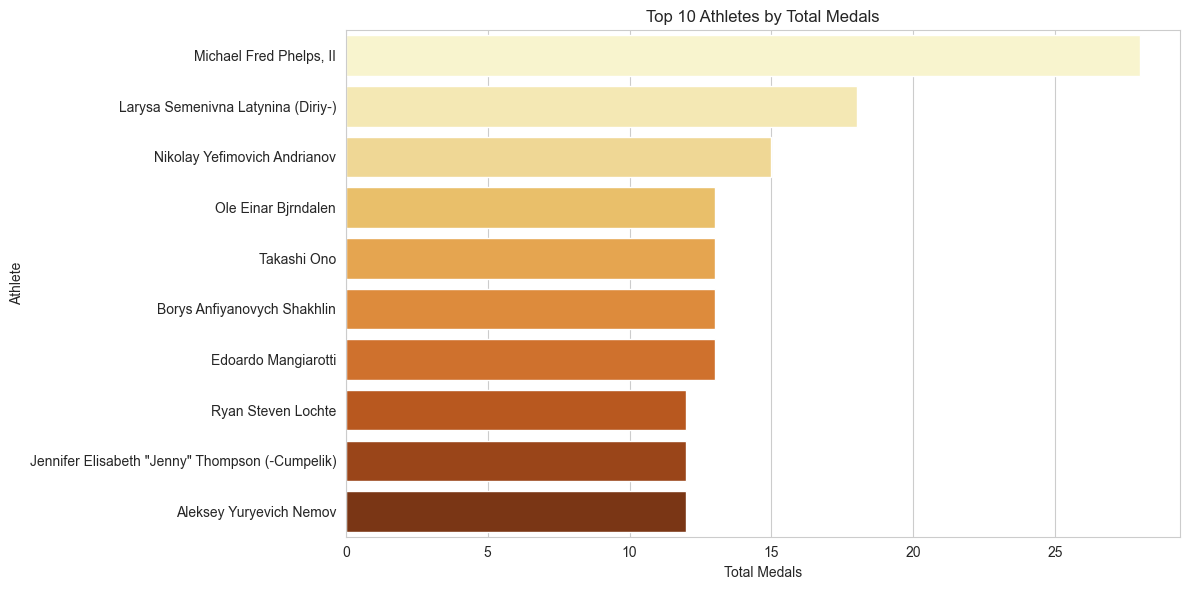

In [37]:
top_athletes = df[df['Medal'] != 'No Medal'].groupby('Name')['Medal'].count().reset_index()
top_athletes.columns = ['Athlete', 'Medals']
top_athletes = top_athletes.sort_values('Medals', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_athletes, x='Medals', y='Athlete', palette='YlOrBr')
plt.title('Top 10 Athletes by Total Medals')
plt.xlabel('Total Medals')
plt.ylabel('Athlete')
plt.tight_layout()
plt.savefig('../graphs/top_athelete.png', dpi=150, bbox_inches='tight')
plt.show()

## 4.5 Sports Analysis

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\2529740475.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_sports, x='Events', y='Sport', palette='Blues_r')


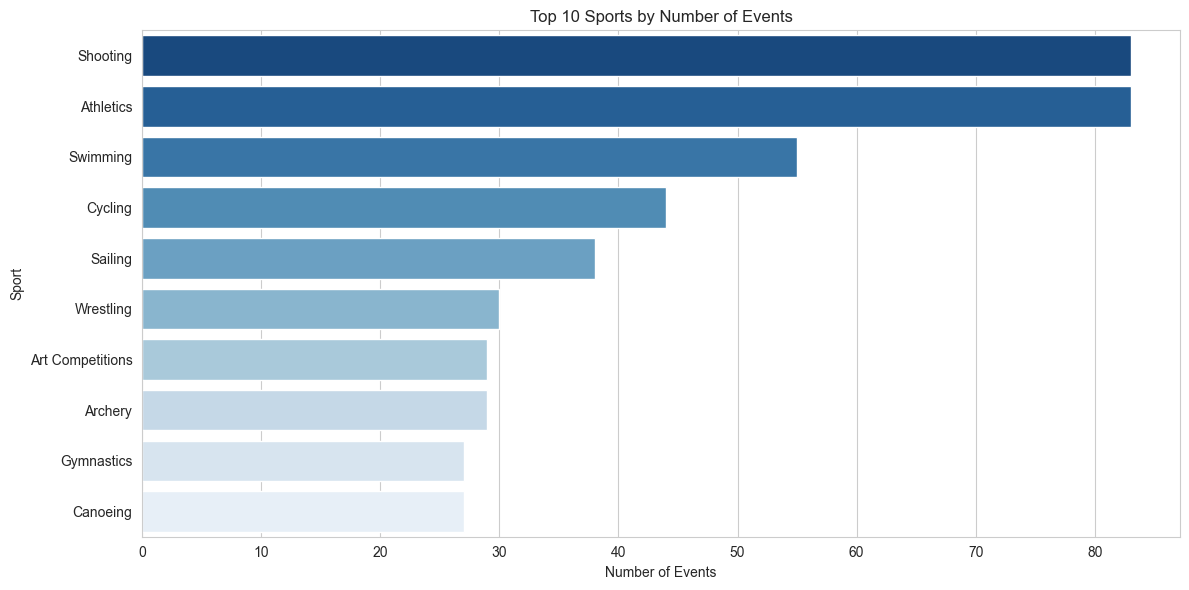

In [38]:
top_sports = df.groupby('Sport')['Event'].nunique().reset_index()
top_sports.columns = ['Sport', 'Events']
top_sports = top_sports.sort_values('Events', ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_sports, x='Events', y='Sport', palette='Blues_r')
plt.title('Top 10 Sports by Number of Events')
plt.xlabel('Number of Events')
plt.ylabel('Sport')
plt.tight_layout()
plt.savefig('../graphs/top_sports.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\84266087.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_age_sport, x='Avg Age', y='Sport', palette='coolwarm')


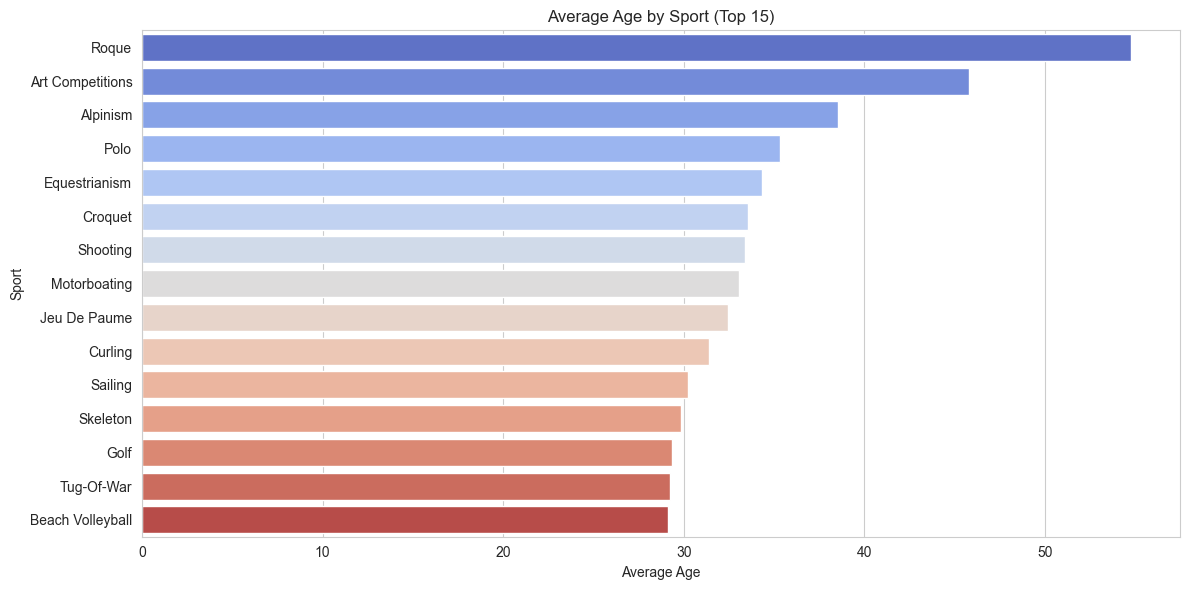

In [39]:
avg_age_sport = df.groupby('Sport')['Age'].mean().reset_index()
avg_age_sport.columns = ['Sport', 'Avg Age']
avg_age_sport = avg_age_sport.sort_values('Avg Age', ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_age_sport, x='Avg Age', y='Sport', palette='coolwarm')
plt.title('Average Age by Sport (Top 15)')
plt.xlabel('Average Age')
plt.ylabel('Sport')
plt.tight_layout()
plt.savefig('../graphs/avg_age_sport.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\3277465919.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=india_sport_count, x='Medals', y='Sport', palette='Greens_r')


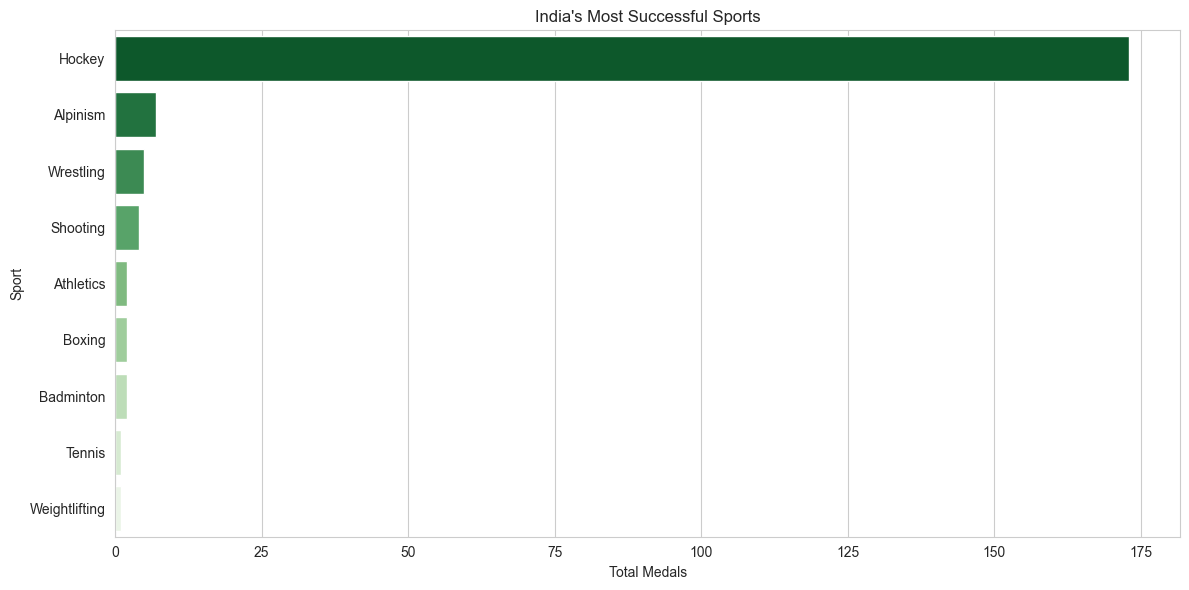

In [40]:
india_sports = df[(df['region'] == 'India') & (df['Medal'] != 'No Medal')]
india_sport_count = india_sports.groupby('Sport')['Medal'].count().reset_index()
india_sport_count.columns = ['Sport', 'Medals']
india_sport_count = india_sport_count.sort_values('Medals', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=india_sport_count, x='Medals', y='Sport', palette='Greens_r')
plt.title("India's Most Successful Sports")
plt.xlabel('Total Medals')
plt.ylabel('Sport')
plt.tight_layout()
plt.savefig('../graphs/india_best_sports.png', dpi=150, bbox_inches='tight')
plt.show()

In [41]:
india_sports.groupby('Sport')['Medal'].count().reset_index()

,Sport,Medal
0,Alpinism,7
1,Athletics,2
2,Badminton,2
3,Boxing,2
4,Hockey,173
5,Shooting,4
6,Tennis,1
7,Weightlifting,1
8,Wrestling,5


# Section 5 — ML Model 1 — Medal Prediction

In [42]:
cols = ['Sex','Age','Height','Weight','Year','Season','Sport','region','Medal_Won']
present = [c for c in cols if c in df.columns]
new_df = df[present].copy()
print("Selected columns:", present)

Selected columns: ['Sex', 'Age', 'Height', 'Weight', 'Year', 'Season', 'Sport', 'region', 'Medal_Won']


In [43]:
new_df.dropna(inplace=True)

In [44]:
new_df

,Sex,Age,Height,Weight,Year,Season,Sport,region,Medal_Won
0,M,24.0,180.0,80.0,1992,Summer,Basketball,China,0
1,M,23.0,170.0,60.0,2012,Summer,Judo,China,0
2,M,24.0,175.0,71.0,1920,Summer,Football,Denmark,0
3,M,34.0,182.0,95.0,1900,Summer,Tug-Of-War,Denmark,1
4,F,21.0,185.0,82.0,1988,Winter,Speed Skating,Netherlands,0
...,...,...,...,...,...,...,...,...,...
271111,M,29.0,179.0,89.0,1976,Winter,Luge,Poland,0
271112,M,27.0,176.0,59.0,2014,Winter,Ski Jumping,Poland,0
271113,M,27.0,176.0,59.0,2014,Winter,Ski Jumping,Poland,0
271114,M,30.0,185.0,96.0,1998,Winter,Bobsleigh,Poland,0


In [45]:
from sklearn.preprocessing import LabelEncoder    

In [46]:
le_sex = LabelEncoder()
new_df['Sex'] = le_sex.fit_transform(new_df['Sex'])

In [47]:
le_season = LabelEncoder()
new_df['Season'] = le_season.fit_transform(new_df['Season'])

In [48]:
new_df = pd.get_dummies(new_df, columns=['Sport', 'region'], drop_first=True)

In [50]:
print(new_df.dtypes)
print(new_df.head())

Sex                                 int64
Age                               float64
Height                            float64
Weight                            float64
Year                                int64
                                   ...   
region_Virgin Islands, British       bool
region_Virgin Islands, US            bool
region_Yemen                         bool
region_Zambia                        bool
region_Zimbabwe                      bool
Length: 276, dtype: object
   Sex   Age  Height  Weight  Year  Season  Medal_Won  Sport_Alpine Skiing  \
0    1  24.0   180.0    80.0  1992       0          0                False   
1    1  23.0   170.0    60.0  2012       0          0                False   
2    1  24.0   175.0    71.0  1920       0          0                False   
3    1  34.0   182.0    95.0  1900       0          1                False   
4    0  21.0   185.0    82.0  1988       1          0                False   

   Sport_Alpinism  Sport_Archery  ...  reg

In [51]:
new_df

,Sex,Age,Height,Weight,Year,Season,Medal_Won,Sport_Alpine Skiing,Sport_Alpinism,Sport_Archery,...,region_Uruguay,region_Uzbekistan,region_Vanuatu,region_Venezuela,region_Vietnam,"region_Virgin Islands, British","region_Virgin Islands, US",region_Yemen,region_Zambia,region_Zimbabwe
0,1,24.0,180.0,80.0,1992,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,23.0,170.0,60.0,2012,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,24.0,175.0,71.0,1920,0,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,34.0,182.0,95.0,1900,0,1,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,21.0,185.0,82.0,1988,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,1,29.0,179.0,89.0,1976,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
271112,1,27.0,176.0,59.0,2014,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
271113,1,27.0,176.0,59.0,2014,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
271114,1,30.0,185.0,96.0,1998,1,0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [52]:
import pickle
pickle.dump(le_sex, open('../models/le_sex.pkl', 'wb'))
pickle.dump(le_season, open('../models/le_season.pkl', 'wb'))

In [53]:
X = new_df.drop('Medal_Won', axis=1)
y = new_df['Medal_Won']

In [54]:
X

,Sex,Age,Height,Weight,Year,Season,Sport_Alpine Skiing,Sport_Alpinism,Sport_Archery,Sport_Art Competitions,...,region_Uruguay,region_Uzbekistan,region_Vanuatu,region_Venezuela,region_Vietnam,"region_Virgin Islands, British","region_Virgin Islands, US",region_Yemen,region_Zambia,region_Zimbabwe
0,1,24.0,180.0,80.0,1992,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,23.0,170.0,60.0,2012,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,24.0,175.0,71.0,1920,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,34.0,182.0,95.0,1900,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,21.0,185.0,82.0,1988,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,1,29.0,179.0,89.0,1976,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
271112,1,27.0,176.0,59.0,2014,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
271113,1,27.0,176.0,59.0,2014,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
271114,1,30.0,185.0,96.0,1998,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((216596, 275), (54150, 275), (216596,), (54150,))

In [57]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [58]:
y_pred = model.predict(X_test)

In [59]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.88533702677747

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.96      0.93     46305
           1       0.64      0.47      0.54      7845

    accuracy                           0.89     54150
   macro avg       0.78      0.71      0.74     54150
weighted avg       0.87      0.89      0.88     54150


Confusion Matrix:
 [[44282  2023]
 [ 4186  3659]]


In [60]:
matrix = confusion_matrix(y_test, y_pred)

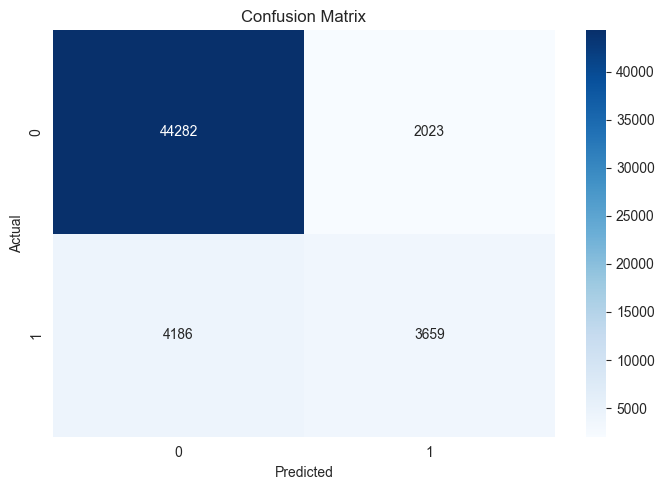

In [61]:
plt.figure(figsize=(7, 5))
sns.heatmap(data=matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../graphs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [62]:
model.feature_importances_

array([1.35477911e-02, 1.68292337e-01, 1.24704335e-01, 1.30960578e-01,
       2.14195356e-01, 5.14412749e-03, 2.15865573e-03, 5.13999143e-04,
       2.20685732e-03, 1.09471934e-03, 6.05042291e-03, 1.16168675e-03,
       2.00315031e-03, 5.31514640e-03, 1.22577677e-05, 6.68402865e-04,
       1.43092756e-03, 1.21444094e-03, 2.82783040e-03, 4.03812315e-03,
       3.53534144e-04, 3.88511158e-05, 2.10743227e-03, 1.33612742e-03,
       3.76840110e-03, 2.53965721e-03, 2.75726787e-03, 5.56801238e-03,
       1.35303245e-03, 5.66366933e-03, 6.79165335e-04, 1.86420775e-04,
       4.64445843e-03, 4.16020112e-03, 5.77724531e-03, 5.38758290e-03,
       2.78690161e-05, 2.48120874e-03, 7.56598642e-04, 1.22747161e-03,
       1.53327801e-04, 1.34904452e-03, 3.88860924e-05, 7.04597428e-04,
       8.60638850e-04, 1.16642492e-04, 9.28864867e-04, 2.73997603e-05,
       6.67529208e-03, 2.85401918e-03, 6.47611599e-04, 4.11308827e-03,
       2.98345958e-03, 1.24752789e-03, 3.12084659e-04, 9.82442037e-04,
      

In [66]:
feature_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

In [67]:
feature_df

,Feature,Importance
4,Year,0.214195
1,Age,0.168292
3,Weight,0.130961
2,Height,0.124704
261,region_USA,0.023452
221,region_Russia,0.020498
0,Sex,0.013548
137,region_Germany,0.010173
59,Sport_Swimming,0.008330
103,region_Canada,0.007589


C:\Users\DELL\AppData\Local\Temp\ipykernel_12864\3581535609.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')


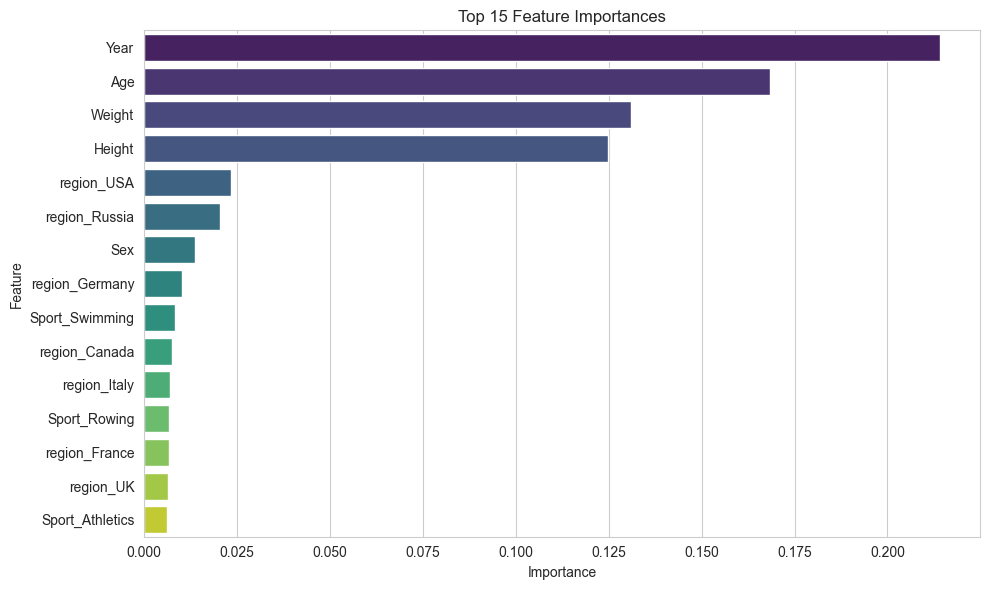

In [68]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig("../graphs/feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

In [69]:
pickle.dump(model, open('../models/medal_model.pkl', 'wb'))

# Section 6 — ML Model 2 — Athlete Clustering

In [70]:
cluster_df = df[["Age", "Height", "Weight"]].dropna()

In [71]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df)
scaled_df = pd.DataFrame(scaled_features, columns=cluster_df.columns)

In [72]:
scaled_df.head()

,Age,Height,Weight
0,-0.249748,0.499427,0.723665
1,-0.406798,-0.535648,-0.807478
2,-0.249748,-0.018111,0.034651
3,1.320747,0.706442,1.872022
4,-0.720897,1.016964,0.876779


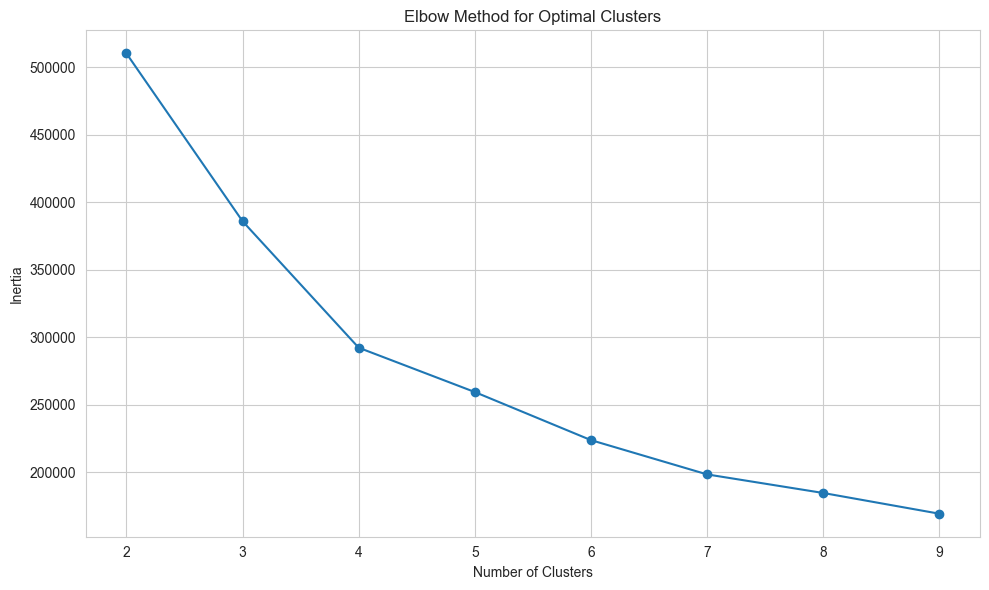

In [74]:
from sklearn.cluster import KMeans
inertia = []
for i in range(2, 10):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(range(2, 10), inertia, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout() 
plt.show()

In [82]:
kmeans = KMeans(n_clusters=4, random_state=42)
scaled_df['Cluster'] = kmeans.fit_predict(scaled_df)

In [83]:
cluster_df['Cluster'] = kmeans.labels_

In [84]:
scaled_df

,Age,Height,Weight,Cluster
0,-0.249748,0.499427,0.723665,0
1,-0.406798,-0.535648,-0.807478,3
2,-0.249748,-0.018111,0.034651,0
3,1.320747,0.706442,1.872022,1
4,-0.720897,1.016964,0.876779,1
...,...,...,...,...
270741,0.535500,0.395919,1.412679,1
270742,0.221400,0.085397,-0.884035,0
270743,0.221400,0.085397,-0.884035,0
270744,0.692549,1.016964,1.948579,1


In [85]:
cluster_df.value_counts('Cluster')

Cluster
0    114756
3     68623
1     56647
2     30720
Name: count, dtype: int64

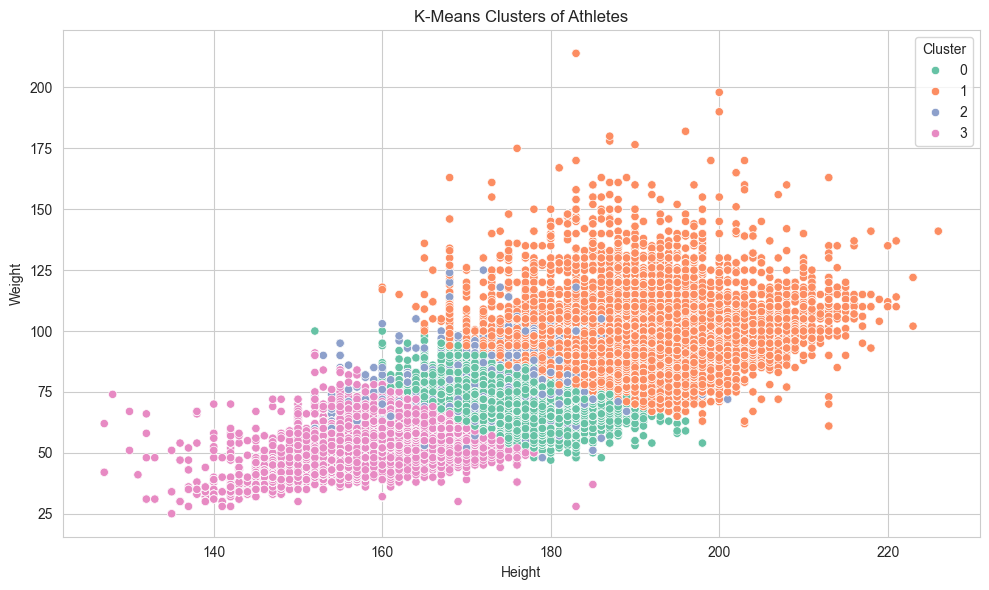

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=cluster_df, x='Height', y='Weight', hue='Cluster', palette='Set2')
plt.title('K-Means Clusters of Athletes')
plt.xlabel('Height')
plt.ylabel('Weight')
plt.legend(title='Cluster')
plt.tight_layout()
plt.savefig("../graphs/kmeans_clusters.png", dpi=150, bbox_inches='tight')
plt.show()

In [87]:
cols = ["Age", "Height", "Weight"]
cluster_means = cluster_df.groupby(cluster_df['Cluster'])[cols].mean().reset_index()
cluster_means

,Cluster,Age,Height,Weight
0,0,23.806398,176.145653,70.018596
1,1,25.584815,187.572193,88.211803
2,2,38.153548,174.621859,71.849382
3,3,22.953689,163.565656,56.267170


In [89]:
table = pd.pivot_table(cluster_df, index='Cluster', values=['Age','Height','Weight'], aggfunc='mean').round(1)
table

,Age,Height,Weight
Cluster,,,
0,23.8,176.1,70.0
1,25.6,187.6,88.2
2,38.2,174.6,71.8
3,23.0,163.6,56.3


In [90]:
pickle.dump(model, open('../models/athelete_clustering.pkl', 'wb'))

Cluster 2 stands out with average age 38.2 — significantly older than 
other clusters. These likely represent precision and skill based sports 
like Equestrian and Shooting where experience matters more than physical 
peak performance.